# Exploratory Data Analysis

## Setup

### Libraries

In [12]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

from pyspark.sql import functions as F
from pyspark.sql import Window
from src.config import DATA_DIR
from src.data.aggregate import get_spark

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data

In [3]:
spark = get_spark()
weekly = spark.read.parquet(str(DATA_DIR / "weekly.parquet"))
print("rows:", weekly.count())   # 8_445_730

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/10 11:11:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


rows: 8445730


## EDA-1 -- Overview

In [5]:
# Number of series (item x store) — sanity check
n_series = weekly.select("id").distinct().count()
print("series:", n_series)   # attendu : 30490

# What proportion of (series, week) are at 0 sales ?
zero_share = weekly.filter(F.col("sales") == 0).count() / weekly.count()
print(f"Share of weeks with 0 sales : {zero_share:.1%}")

# Weekly sales distribution by quantile
weekly.select("sales").summary(
    "min", "25%", "50%", "75%", "90%", "99%", "max"
).show()

series: 30490
Share of weeks with 0 sales : 39.7%


+-------+-----+
|summary|sales|
+-------+-----+
|    min|    0|
|    25%|    0|
|    50%|    2|
|    75%|    7|
|    90%|   19|
|    99%|   94|
|    max| 3539|
+-------+-----+



## EDA-1 -- Volume & 0-sales week overview

- **30,490 series** (item × store), each spanning 277 full weeks after partial-week removal.
- **39.7% of (series, week) cells have zero sales** — weekly aggregation fills many
  daily zeros (a slow mover selling once a week is ~85% zeros daily but near-0%
  weekly). The weekly grain already dampens intermittency by design.
- This 39.7% still includes **cold-start zeros** (weeks before a product was
  introduced in a store), so true demand intermittency is lower still — to be
  isolated in EDA-2.
- **Weekly sales are right-skewed** but not pathological: median = 2, Q3 = 7,
  P90 = 19, P99 = 94, max = 3,539. Half of all weeks have ≥ 2 sales, so a
  meaningful share of series are dense enough for z-score-based signals.
- The gap between a zero Q1 and a non-zero median suggests zeros are
  **concentrated in a sub-population of sparse series** rather than spread
  uniformly — motivating the dense/intermittent segmentation (EDA-3) and
  predicting a bimodal density distribution.
- **Modeling implication:** a naive z-score can't be applied blindly across all
  series; injection-based evaluation will be restricted to the dense pool.

## EDA-2 -- Remove zero-sales week

In [9]:
def trim_cold_start(weekly):
    """Remove leading zero-sales weeks (before a product's first real sale).

    For each series, find the week of its first non-zero sale, then keep only
    weeks at or after it. Leading zeros are 'not yet stocked', not 'zero demand'
    — keeping them would understate density for recently introduced products.
    """
    # First sale = smallest wm_yr_wk where sales > 0, per series.
    first_sale = (
        weekly
        .filter(F.col("sales") > 0)
        .groupBy("id")
        .agg(F.min("wm_yr_wk").alias("first_sale_week"))
    )

    trimmed = (
        weekly.join(first_sale, on="id", how="inner")
        .filter(F.col("wm_yr_wk") >= F.col("first_sale_week"))
    )
    return trimmed

In [8]:
trimmed = trim_cold_start(weekly)

print("rows before:", weekly.count())     # 8_445_730
print("rows after :", trimmed.count())    # < 8_445_730

# Le nouveau poids des zéros — la "vraie" intermittence de demande
zero_share_after = trimmed.filter(F.col("sales") == 0).count() / trimmed.count()
print(f"zero share after trim: {zero_share_after:.1%}")   # < 39.7%

rows before: 8445730


rows after : 6686246


zero share after trim: 23.9%


## EDA-2 -- Cold-start trimming

- Removed **1,759,484 leading zero weeks (21% of the raw grid)** — cells before
  each product's first real sale, i.e. "not yet stocked" rather than zero demand.
- Zero share drops from **39.7% → 23.9%** after trimming: ~16 points of the
  apparent intermittency was a product-lifecycle artifact, not demand sparsity.
- Series now have **variable life spans** (recently introduced products span
  fewer weeks); density will be computed over each series' effective life, not a
  uniform 277-week window.
- **True weekly demand intermittency is moderate (23.9%)**, consistent with the
  non-zero median — the dense pool for injection-based evaluation should be
  sizable.

## EDA-3 -- Series density and distribution

In [10]:
def compute_density(trimmed):
    """Density per series = share of active weeks with non-zero sales,
    over the series' effective life (post cold-start trim)."""
    density = (
        trimmed.groupBy("id", "item_id", "dept_id", "cat_id", "store_id", "state_id")
        .agg(
            F.count("*").alias("life_weeks"),
            F.sum(F.when(F.col("sales") > 0, 1).otherwise(0)).alias("active_weeks"),
        )
        .withColumn("density", F.col("active_weeks") / F.col("life_weeks"))
    )
    return density

In [11]:
# Computation using Spark then saved as pandas df
density = compute_density(trimmed)
density_pd = density.select(
    "id", "cat_id", "dept_id", "state_id", "life_weeks", "active_weeks", "density"
).toPandas()

print("séries:", len(density_pd))   # 30490
print(density_pd["density"].describe())

séries: 30490
count    30490.000000
mean         0.762053
std          0.195172
min          0.037736
25%          0.639344
50%          0.807692
75%          0.924188
max          1.000000
Name: density, dtype: float64


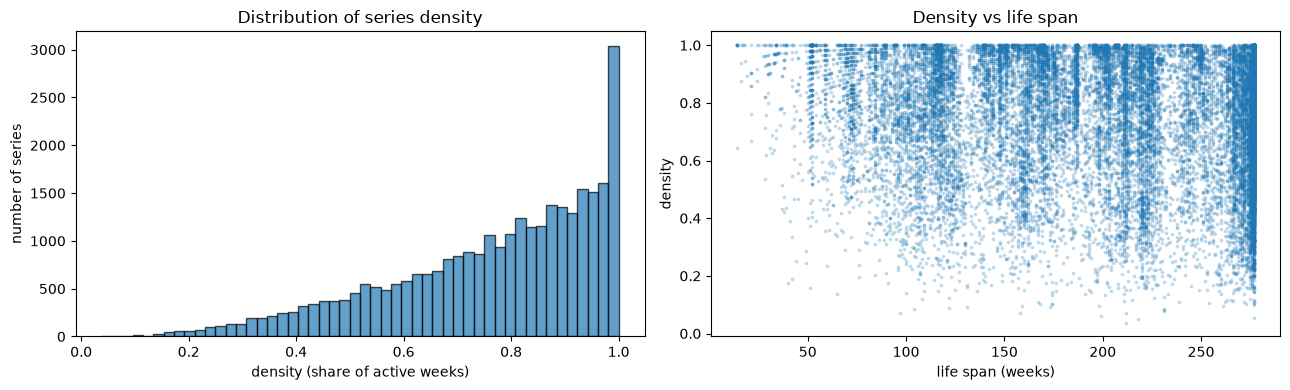

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme des densités — c'est ICI qu'on lit la bimodalité (ou non)
ax[0].hist(density_pd["density"], bins=50, edgecolor="black", alpha=0.7)
ax[0].set_xlabel("density (share of active weeks)")
ax[0].set_ylabel("number of series")
ax[0].set_title("Distribution of series density")

# Densité vs durée de vie — pour repérer un éventuel effet cycle de vie résiduel
ax[1].scatter(density_pd["life_weeks"], density_pd["density"], s=3, alpha=0.2)
ax[1].set_xlabel("life span (weeks)")
ax[1].set_ylabel("density")
ax[1].set_title("Density vs life span")

plt.tight_layout()
plt.show()

In [14]:
for thr in [0.6, 0.7, 0.8, 0.9]:
    n = (density_pd["density"] >= thr).sum()
    print(f"density >= {thr}: {n:5d} series ({n/len(density_pd):.1%})")

density >= 0.6: 24191 series (79.3%)
density >= 0.7: 20607 series (67.6%)
density >= 0.8: 15688 series (51.5%)
density >= 0.9:  9312 series (30.5%)


In [16]:
DENSITY_THR = 0.8
MIN_LIFE_WEEKS = 52

dense_mask = (density_pd["density"] >= DENSITY_THR) & (density_pd["life_weeks"] >= MIN_LIFE_WEEKS)
print(f"dense pool: {dense_mask.sum()} series ({dense_mask.mean():.1%})")

# Distribution by category to avoid bias towards one of them
print(density_pd[dense_mask]["cat_id"].value_counts())

dense pool: 15509 series (50.9%)
cat_id
FOODS        8235
HOUSEHOLD    5056
HOBBIES      2218
Name: count, dtype: int64


## EDA-3 -- Density distribution & dense-pool definition

- Density (share of active weeks over effective life) forms a **continuous,
  right-rising distribution — no bimodality, no natural gap.** Dense and sparse
  series lie on a continuum, not in two separable populations.
- Density is **uncorrelated with life span** (scatter), confirming cold-start
  trimming left no residual lifecycle effect.
- With no natural cut, the threshold is set by **evaluation need, not
  distribution shape**: a rolling z-score / reconstruction error requires a
  well-defined local variance, which degrades below ~0.8 density.
- **Dense pool = density ≥ 0.8 AND life span ≥ 52 weeks** (the 52-week floor
  guarantees the year-over-year seasonal-deviation feature is computable).
- Pool size is not a constraint: 51.5% of series pass density ≥ 0.8 alone;
  the combined criterion retains 15509 series across all three categories.